In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [28]:
# 2️⃣ Load Dataset

df = pd.read_csv('spam.csv', encoding='latin1')

# Hapus kolom yang tidak digunakan
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

# Ganti nama kolom agar mudah dipahami
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})

# Buat kolom label numerik (ham=0, spam=1)
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

# Tampilkan 5 data pertama
print("✅ Dataset berhasil dimuat!")
df.head()


✅ Dataset berhasil dimuat!


,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


Jumlah data spam dan ham:
label
ham     4825
spam     747
Name: count, dtype: int64


/tmp/ipython-input-1747571980.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='pastel')


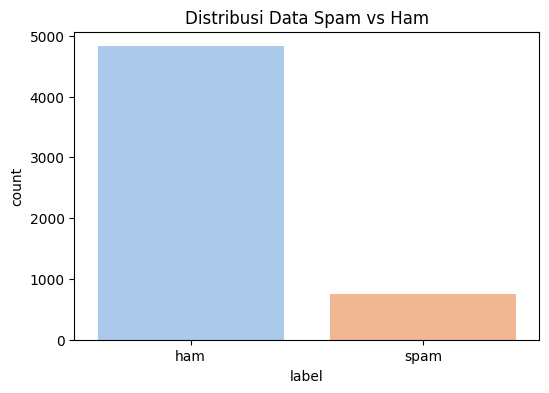

Jumlah data kosong per kolom:
label        0
Text         0
label_enc    0
dtype: int64


In [29]:
# 3️⃣ Eksplorasi Data
print("Jumlah data spam dan ham:")
print(df['label'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='pastel')
plt.title('Distribusi Data Spam vs Ham')
plt.show()

# Cek apakah ada nilai kosong
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())


In [30]:
# 4️⃣ Preprocessing Data
# Tokenisasi teks
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['Text'])
sequences = tokenizer.texts_to_sequences(df['Text'])

# Padding agar panjang input seragam
max_length = 100
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

# Pisahkan data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    padded, df['label_enc'], test_size=0.2, random_state=42
)

print("✅ Data berhasil diproses dan siap digunakan!")


✅ Data berhasil diproses dan siap digunakan!


In [31]:
# 5️⃣ Membangun Model LSTM
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Tampilkan arsitektur model
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
# 6️⃣ Compile dan Training Model
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.8503 - loss: 0.4873 - val_accuracy: 0.8655 - val_loss: 0.3961
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.8738 - loss: 0.3959 - val_accuracy: 0.8655 - val_loss: 0.3956
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.8676 - loss: 0.4032 - val_accuracy: 0.8655 - val_loss: 0.3965
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.8652 - loss: 0.4109 - val_accuracy: 0.8655 - val_loss: 0.3969


✅ Akurasi Model: 86.55%


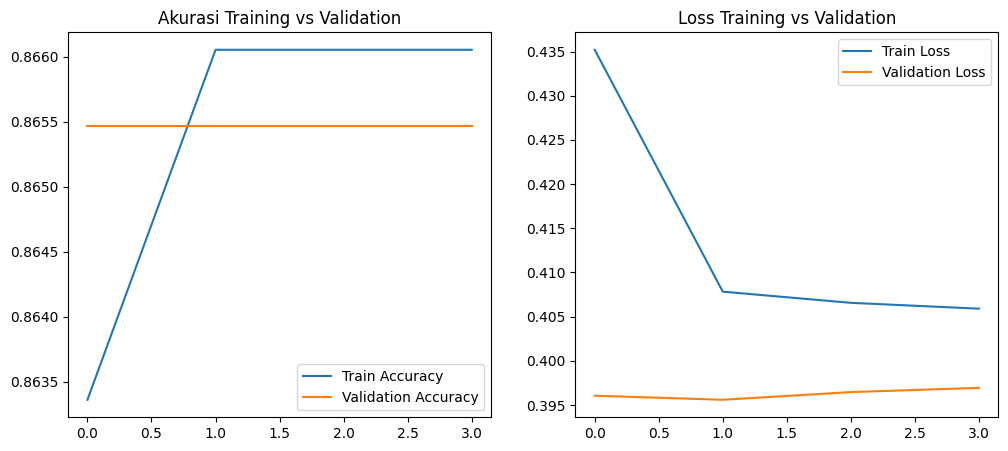

In [33]:
# 7️⃣ Evaluasi Model
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Akurasi Model: {acc*100:.2f}%")

# Plot akurasi dan loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Akurasi Training vs Validation')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Training vs Validation')
plt.legend()

plt.show()


In [34]:
# 8️⃣ Uji Coba Prediksi Manual
def predict_message(msg):
    seq = tokenizer.texts_to_sequences([msg])
    pad = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
    pred = model.predict(pad)
    return "🚫 Spam" if pred[0][0] > 0.5 else "✅ Ham"

# Contoh prediksi
print(predict_message("Congratulations! You've won a $1000 gift card!"))
print(predict_message("Hey, are we still meeting tomorrow?"))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
✅ Ham
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
✅ Ham


35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
✅ Akurasi Model: 86.55%


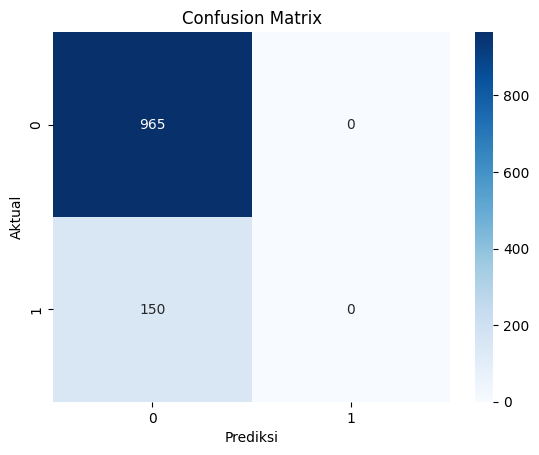

📋 Classification Report:
              precision    recall  f1-score   support

         Ham       0.87      1.00      0.93       965
        Spam       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


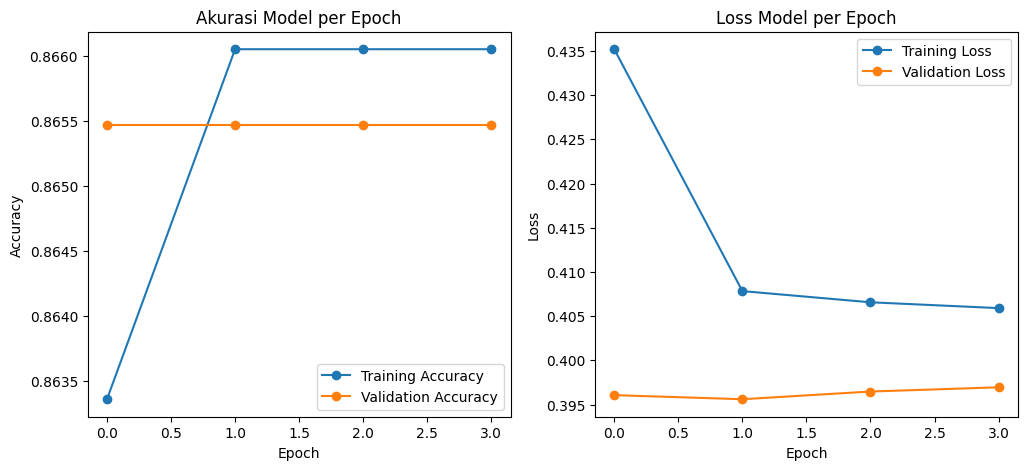

In [35]:
# =====================================================
# 🔹 Evaluasi Model (Akurasi & Visualisasi)
# =====================================================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Prediksi pada data uji
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Hitung akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Akurasi Model: {accuracy*100:.2f}%")

# Tampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Classification Report
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Plot akurasi dan loss selama training
plt.figure(figsize=(12,5))

# Plot akurasi
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Akurasi Model per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Model per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


After uploading the file, you can read it into a pandas DataFrame like this: